# SVM Cat vs Dog Classifier

**Dataset:** [Microsoft Cats vs Dogs](https://www.microsoft.com/en-us/download/details.aspx?id=54765) — sourced via `tensorflow_datasets` (25,000 labeled images, ~12.5K per class).

**Pipeline:**
1. Load a balanced subset via `tensorflow_datasets`
2. Resize images → flatten → optionally apply PCA
3. Train a **LinearSVC** (fast) or **RBF-kernel SVC**
4. Evaluate with accuracy, confusion matrix & classification report
5. Visualise predictions on sample images

In [15]:
!pip install -q tensorflow-datasets scikit-learn matplotlib seaborn tqdm

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import tensorflow_datasets as tfds
import tensorflow as tf

from sklearn.svm import LinearSVC, SVC
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.model_selection import cross_val_score

import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
print('Libraries loaded ✅')

Libraries loaded ✅


In [17]:
IMG_SIZE    = 64      # resize to IMG_SIZE × IMG_SIZE (trade-off: quality vs speed)
N_TRAIN     = 3000    # samples for training   (increase for better accuracy)
N_TEST      = 1000    # samples for evaluation
N_PCA       = 150     # PCA components (set None to skip PCA)
USE_LINEAR  = True    # True → LinearSVC (fast)  |  False → RBF SVC (slower, often better)
C_VALUE     = 1.0     # regularisation strength

LABELS = {0: 'Cat', 1: 'Dog'}
print(f'Config: {IMG_SIZE}px images | {N_TRAIN} train | {N_TEST} test | PCA={N_PCA} | LinearSVC={USE_LINEAR}')

Config: 64px images | 3000 train | 1000 test | PCA=150 | LinearSVC=True


In [18]:
# Dataset: "cats_vs_dogs" (Microsoft Cats & Dogs, 25 000 images)
# tfds handles download + caching automatically.

print('Downloading / loading dataset … (first run may take a few minutes)')
ds_full, info = tfds.load(
    'cats_vs_dogs',
    split='train',          # only a single 'train' split exists in this dataset
    as_supervised=True,
    with_info=True,
    shuffle_files=True
)
print(f'Total images available: {info.splits["train"].num_examples:,}')
print(info.features)

Total images available: 23,262
FeaturesDict({
    'image': Image(shape=(None, None, 3), dtype=uint8),
    'image/filename': Text(shape=(), dtype=string),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
})


In [19]:
def preprocess(image, label):
    """Resize, normalise to [0,1], flatten."""
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def dataset_to_numpy(ds, n_samples):
    """Extract n_samples (image, label) pairs as numpy arrays."""
    ds = ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.take(n_samples).batch(256).prefetch(tf.data.AUTOTUNE)
    X_list, y_list = [], []
    for imgs, labels in tqdm(ds, desc='Loading batches'):
        X_list.append(imgs.numpy().reshape(imgs.shape[0], -1))
        y_list.append(labels.numpy())
    return np.concatenate(X_list), np.concatenate(y_list)

# Shuffle once, then split
ds_shuffled = ds_full.shuffle(buffer_size=10_000, seed=SEED, reshuffle_each_iteration=False)

print('Building train set …')
X_train, y_train = dataset_to_numpy(ds_shuffled, N_TRAIN)

print('Building test set …')
X_test, y_test = dataset_to_numpy(ds_shuffled.skip(N_TRAIN), N_TEST)

print(f'\nX_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}   y_test : {y_test.shape}')
print(f'Class balance (train) — Cat: {(y_train==0).sum()}  Dog: {(y_train==1).sum()}')

Building train set …


Loading batches:   0%|          | 0/12 [00:00<?, ?it/s]

Building test set …


Loading batches:   0%|          | 0/4 [00:00<?, ?it/s]


X_train: (3000, 12288)  y_train: (3000,)
X_test : (1000, 12288)   y_test : (1000,)
Class balance (train) — Cat: 1502  Dog: 1498


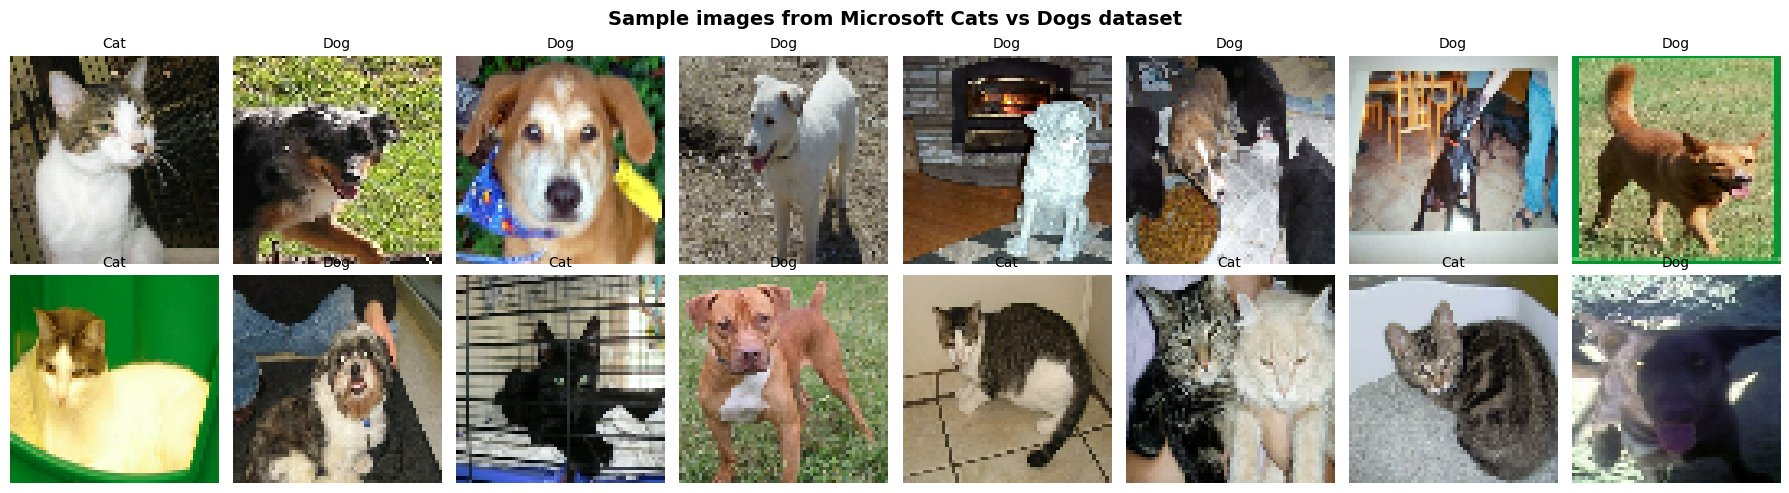

In [20]:
# Re-load a handful of raw images for display
sample_images, sample_labels = [], []
for img, lbl in ds_full.map(preprocess).take(16):
    sample_images.append(img.numpy())
    sample_labels.append(lbl.numpy())

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
fig.suptitle('Sample images from Microsoft Cats vs Dogs dataset', fontsize=14, fontweight='bold')
for ax, img, lbl in zip(axes.flat, sample_images, sample_labels):
    ax.imshow(img)
    ax.set_title(LABELS[lbl], fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [21]:
steps = [('scaler', StandardScaler())]

if N_PCA:
    steps.append(('pca', PCA(n_components=N_PCA, random_state=SEED)))

if USE_LINEAR:
    svm = LinearSVC(C=C_VALUE, max_iter=2000, random_state=SEED)
else:
    svm = SVC(kernel='rbf', C=C_VALUE, gamma='scale', random_state=SEED)

steps.append(('svm', svm))
pipeline = Pipeline(steps)

print('Pipeline:')
for name, step in pipeline.steps:
    print(f'  {name}: {step}')

Pipeline:
  scaler: StandardScaler()
  pca: PCA(n_components=150, random_state=42)
  svm: LinearSVC(max_iter=2000, random_state=42)


In [22]:
import time
print('Training SVM pipeline …')
t0 = time.time()
pipeline.fit(X_train, y_train)
elapsed = time.time() - t0
print(f'Training complete in {elapsed:.1f}s ✅')

Training SVM pipeline …
Training complete in 9.9s ✅


In [23]:
y_pred = pipeline.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f'Test Accuracy : {acc*100:.2f}%')
print()
print(classification_report(y_test, y_pred, target_names=['Cat', 'Dog']))

Test Accuracy : 57.60%

              precision    recall  f1-score   support

         Cat       0.56      0.57      0.57       482
         Dog       0.59      0.58      0.59       518

    accuracy                           0.58      1000
   macro avg       0.58      0.58      0.58      1000
weighted avg       0.58      0.58      0.58      1000



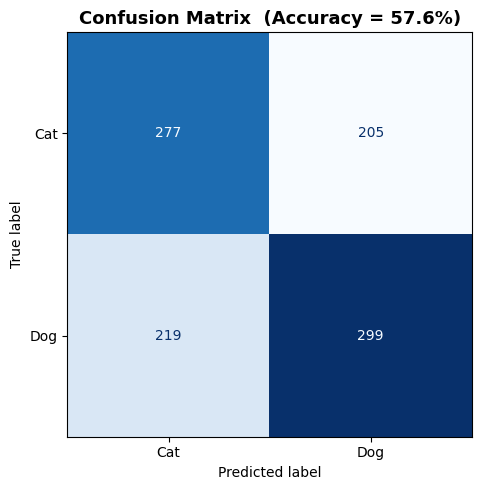

In [24]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Cat', 'Dog'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix  (Accuracy = {acc*100:.1f}%)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

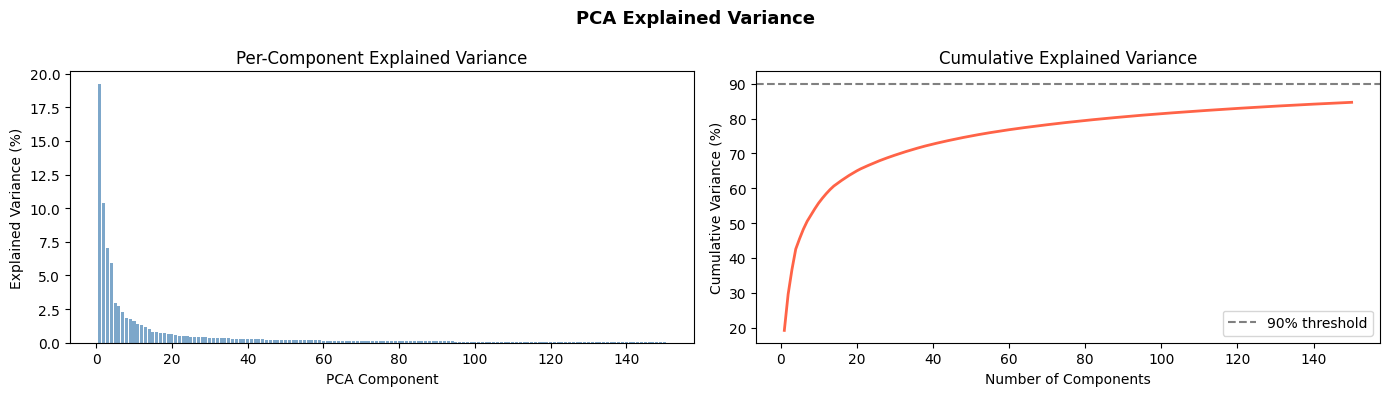

Variance retained with 150 components: 84.6%


In [25]:
if N_PCA:
    pca = pipeline.named_steps['pca']
    cumvar = np.cumsum(pca.explained_variance_ratio_) * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].bar(range(1, N_PCA+1), pca.explained_variance_ratio_*100,
                color='steelblue', alpha=0.7)
    axes[0].set_xlabel('PCA Component')
    axes[0].set_ylabel('Explained Variance (%)')
    axes[0].set_title('Per-Component Explained Variance')

    axes[1].plot(range(1, N_PCA+1), cumvar, color='tomato', linewidth=2)
    axes[1].axhline(90, linestyle='--', color='gray', label='90% threshold')
    axes[1].set_xlabel('Number of Components')
    axes[1].set_ylabel('Cumulative Variance (%)')
    axes[1].set_title('Cumulative Explained Variance')
    axes[1].legend()

    plt.suptitle('PCA Explained Variance', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(f'Variance retained with {N_PCA} components: {cumvar[-1]:.1f}%')

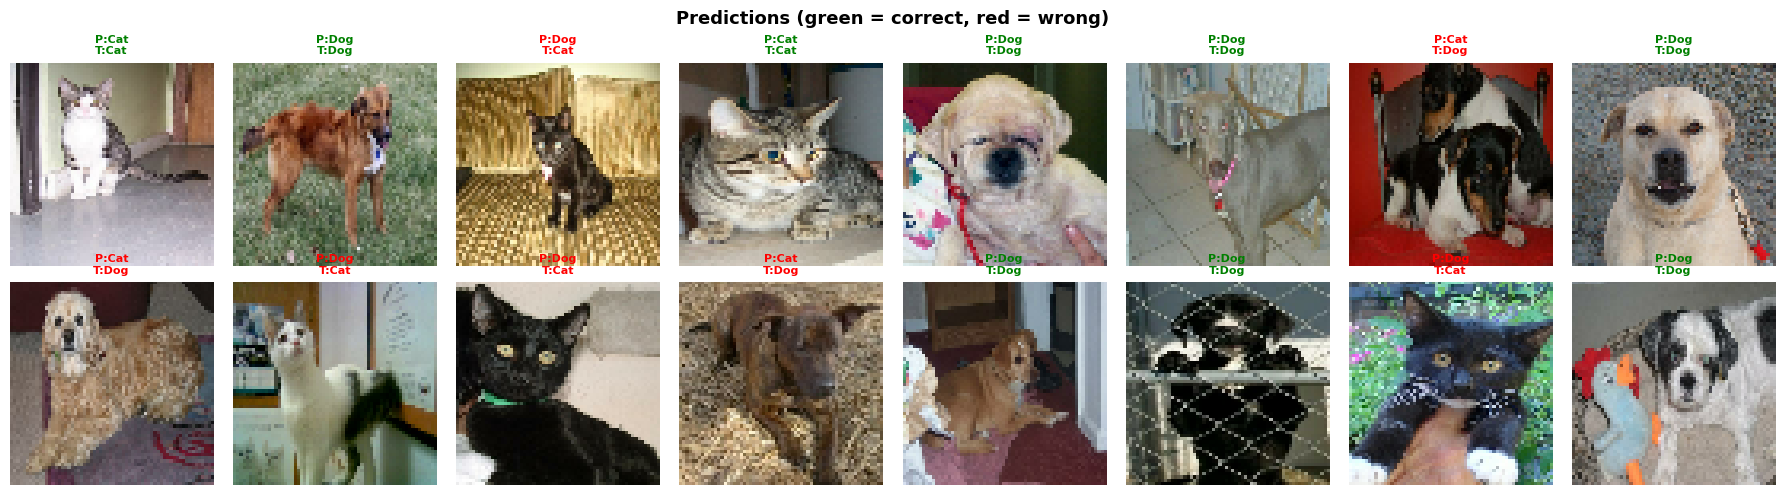

In [26]:
n_show = 16
raw_imgs_test, raw_lbls_test = [], []
for img, lbl in ds_full.map(preprocess).skip(N_TRAIN).take(n_show):
    raw_imgs_test.append(img.numpy())
    raw_lbls_test.append(lbl.numpy())

preds_show = pipeline.predict(
    np.array(raw_imgs_test).reshape(n_show, -1)
)

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
fig.suptitle('Predictions (green = correct, red = wrong)', fontsize=13, fontweight='bold')
for ax, img, true_lbl, pred_lbl in zip(axes.flat, raw_imgs_test, raw_lbls_test, preds_show):
    ax.imshow(img)
    color = 'green' if true_lbl == pred_lbl else 'red'
    ax.set_title(f'P:{LABELS[pred_lbl]}\nT:{LABELS[true_lbl]}',
                 fontsize=8, color=color, fontweight='bold')
    ax.axis('off')
plt.tight_layout()
plt.show()